# 01 — Exploratory QA

Distributions and correlations for the merged D=3 embedding.


### Distributions, correlations, direction norms

**Method:** Reload `cache/merged.parquet` from notebook `00`. `normalize_direction_nd` L2-normalizes all `Inf.Pos.*` rows to the unit sphere in ℝⁿ. The **histogram** is the marginal of `Inf.Hyp.Rad`. There are **two** Pearson correlation heatmaps: (1) **raw** `Inf.Pos.*`, `Inf.Kappa`, `Inf.Hyp.Rad` as stored in the file; (2) **normalized** direction components (same geometry as later UMAP / Lorentz-style steps) plus **`log1p(Inf.Kappa)`** and **`log1p(Inf.Hyp.Rad)`**, matching the scale choices in notebooks `03` and `07`.

**How to read the output:** Printed direction norms should be ~1.0. Compare the two heatmaps: strong structure in (1) that **disappears** in (2) is often a scale / magnitude artifact on raw `Inf.Pos.*`; structure that **remains** in (2) is more relevant to analyses that use unit directions and log scalars.


direction row norms (should be ~1): [1. 1. 1. 1. 1.]


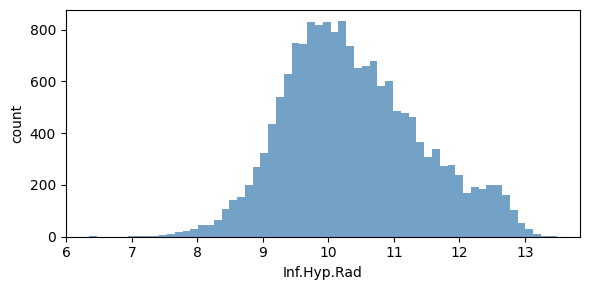

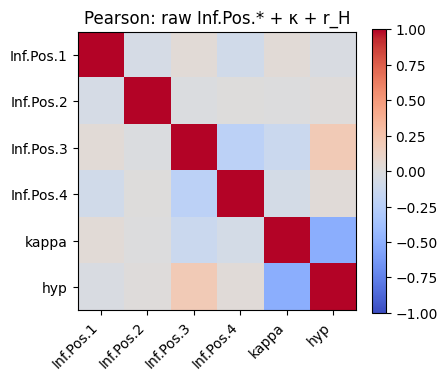

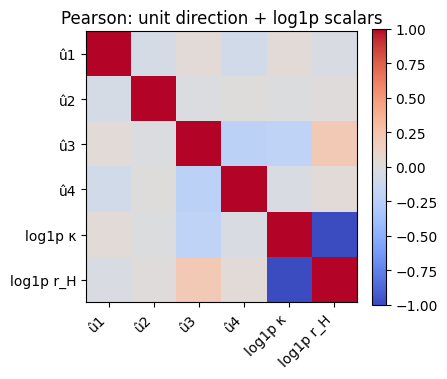

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import dmercator3d_io as dm

merged = dm.load_merged_parquet(Path("cache/merged.parquet"))
pos_cols = sorted([c for c in merged.columns if c.startswith("Inf.Pos.")], key=lambda c: int(c.split(".")[-1]))
U = dm.normalize_direction_nd(merged)
print("direction row norms (should be ~1):", np.linalg.norm(U, axis=1)[:5])

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(merged["Inf.Hyp.Rad"], bins=60, color="steelblue", alpha=0.75)
ax.set_xlabel("Inf.Hyp.Rad")
ax.set_ylabel("count")
fig.tight_layout()

fig2, ax2 = plt.subplots(figsize=(4.5, 4))
C = np.corrcoef(merged[pos_cols + ["Inf.Kappa", "Inf.Hyp.Rad"]].to_numpy().T)
im = ax2.imshow(C, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(pos_cols) + 2))
ax2.set_yticks(range(len(pos_cols) + 2))
labs = pos_cols + ["kappa", "hyp"]
ax2.set_xticklabels(labs, rotation=45, ha="right")
ax2.set_yticklabels(labs)
ax2.set_title("Pearson: raw Inf.Pos.* + κ + r_H")
fig2.colorbar(im, ax=ax2, fraction=0.046)
fig2.tight_layout()

# Second heatmap: unit directions + log scalars (same spirit as 03 / 07)
log_k = np.log1p(merged["Inf.Kappa"].to_numpy(dtype=np.float64))
log_h = np.log1p(merged["Inf.Hyp.Rad"].to_numpy(dtype=np.float64))
feat = np.hstack([U, log_k[:, None], log_h[:, None]])
C2 = np.corrcoef(feat.T)
C2 = np.nan_to_num(C2, nan=0.0, posinf=1.0, neginf=-1.0)
np.fill_diagonal(C2, 1.0)  # corrcoef diagonal should be 1; fix after nan_to_num if needed

fig3, ax3 = plt.subplots(figsize=(4.5, 4))
im3 = ax3.imshow(C2, cmap="coolwarm", vmin=-1, vmax=1)
n_dir = U.shape[1]
ax3.set_xticks(range(n_dir + 2))
ax3.set_yticks(range(n_dir + 2))
labs2 = [f"û{i+1}" for i in range(n_dir)] + ["log1p κ", "log1p r_H"]
ax3.set_xticklabels(labs2, rotation=45, ha="right")
ax3.set_yticklabels(labs2)
ax3.set_title("Pearson: unit direction + log1p scalars")
fig3.colorbar(im3, ax=ax3, fraction=0.046)
fig3.tight_layout()
plt.show()
